## Análise da Ortogonalidade do Modelo
Nesta etapa, extraímos os vetores $V_{piloto}$ e $V_{equipe}$ do conjunto de teste (2023) para comparar o modelo com e sem a restrição de ortogonalidade. O objetivo é demonstrar que no modelo com ortogonalidade, as representações são linearmente independentes, gerando um mapa de calor próximo de zero (branco/neutro).

-> Carregando Grafo do RelBench...
-> Carregando e Alinhando CSV Tabular...
-> Train: 1608, Val: 438, Test: 238
Extraindo vetores...
Calculando matriz de similaridade de cosseno...


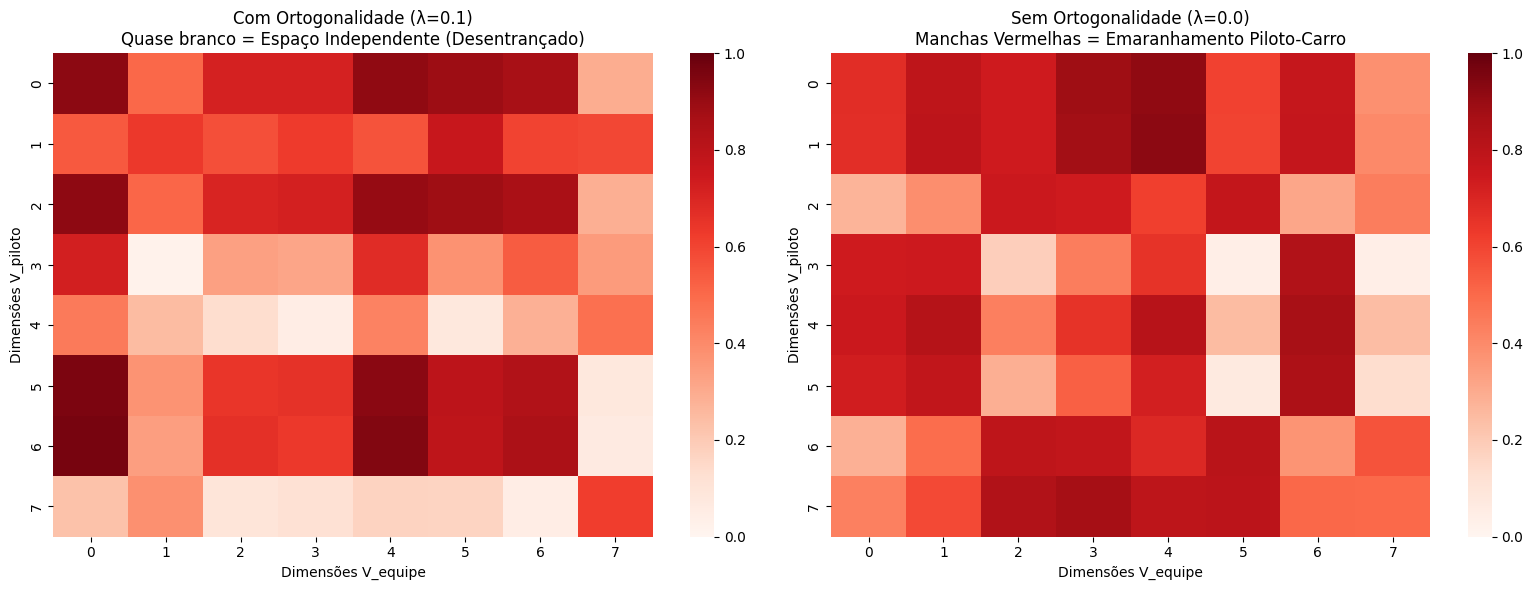

In [2]:
import sys
import os
import torch
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("src"))

from train import prepare_data_and_graph
from models.pipeline_fusion import F1OrthogonalPipeline

# 1. Carregar os dados
train_loader, val_loader, test_loader, graph_data = prepare_data_and_graph()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
graph_data = graph_data.to(device)

# 2. Função para extrair vetores do modelo
def get_vectors(model_name):
    num_nodes_dict = {nt: graph_data[nt].num_nodes for nt in graph_data.node_types}
    model = F1OrthogonalPipeline(num_nodes_dict=num_nodes_dict, latent_dim=8).to(device)
    model.load_state_dict(torch.load(f"output/models/{model_name}.pth", map_location=device))
    model.eval()
    
    all_v_piloto = []
    all_v_equipe = []
    
    with torch.no_grad():
        for batch in test_loader:
            x_driver, x_track, target_constructor_ids, targets = [b.to(device) for b in batch]
            logits, _, _, v_piloto, v_equipe = model(
                x_driver=x_driver, 
                x_track=x_track, 
                graph_x_dict=graph_data.x_dict, 
                graph_edge_index_dict=graph_data.edge_index_dict, 
                target_constructor_ids=target_constructor_ids
            )
            all_v_piloto.append(v_piloto.cpu().numpy())
            all_v_equipe.append(v_equipe.cpu().numpy())
            
    v_piloto_np = np.concatenate(all_v_piloto, axis=0) # (N, 8)
    v_equipe_np = np.concatenate(all_v_equipe, axis=0) # (N, 8)
    return v_piloto_np, v_equipe_np

# 3. Extrair os vetores dos modelos
print("Extraindo vetores...")
v_piloto_orth, v_equipe_orth = get_vectors("model_orthogonal")
v_piloto_no_orth, v_equipe_no_orth = get_vectors("model_no_orthogonal")

# 4. Função atualizada (Cálculo de Similaridade de Cosseno com suporte NumPy)
def calc_cross_similarity_matrix(v_p_tensor, v_e_tensor):
    """
    Calcula a matriz de similaridade de cosseno absoluta média entre 
    todas as dimensões de V_piloto e V_equipe num lote N.
    """
    # Converte para PyTorch Tensor caso seja um array do NumPy
    if isinstance(v_p_tensor, np.ndarray):
        v_p_tensor = torch.tensor(v_p_tensor, dtype=torch.float32)
    if isinstance(v_e_tensor, np.ndarray):
        v_e_tensor = torch.tensor(v_e_tensor, dtype=torch.float32)

    # Garante que as entradas não estão zeradas por erro de extração
    if torch.all(v_p_tensor == 0) or torch.all(v_e_tensor == 0):
        print("ALERTA: Um dos tensores está completamente zerado.")
    
    # Verifica variância (se for 0, o modelo sofreu mode collapse)
    if torch.var(v_p_tensor) < 1e-5:
        print("ALERTA: V_piloto tem variância nula (Mode Collapse).")
        
    # Normaliza cada dimensão para ter norma 1 ao longo do dataset
    v_p_norm = F.normalize(v_p_tensor, p=2, dim=0) 
    v_e_norm = F.normalize(v_e_tensor, p=2, dim=0)
    
    # Produto escalar entre a transposta de V_p e V_e (Matriz 8x8)
    sim_matrix = torch.matmul(v_p_norm.T, v_e_norm)
    
    # Retorna o valor absoluto em formato NumPy
    return torch.abs(sim_matrix).detach().cpu().numpy()

print("Calculando matriz de similaridade de cosseno...")
sim_orth = calc_cross_similarity_matrix(v_piloto_orth, v_equipe_orth)
sim_no_orth = calc_cross_similarity_matrix(v_piloto_no_orth, v_equipe_no_orth)

# 5. Plotar os Mapas de Calor (Escala atualizada para 0 a 1 absoluta)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(sim_orth, ax=axes[0], cmap="Reds", vmin=0, vmax=1)
axes[0].set_title("Com Ortogonalidade (λ=0.1)\nQuase branco = Espaço Independente (Desentrançado)")
axes[0].set_xlabel("Dimensões V_equipe")
axes[0].set_ylabel("Dimensões V_piloto")

sns.heatmap(sim_no_orth, ax=axes[1], cmap="Reds", vmin=0, vmax=1)
axes[1].set_title("Sem Ortogonalidade (λ=0.0)\nManchas Vermelhas = Emaranhamento Piloto-Carro")
axes[1].set_xlabel("Dimensões V_equipe")
axes[1].set_ylabel("Dimensões V_piloto")

plt.tight_layout()
plt.show()

## Atribuição de Crédito de Shapley: O Duelo de 2021

-> Carregando Grafo do RelBench...
-> Carregando e Alinhando CSV Tabular...
-> Train: 1608, Val: 438, Test: 238
Carregando modelo (Excluir Pista: False)...


100%|██████████| 2/2 [00:00<00:00,  5.47it/s]



 RESULTADO SHAP: GP DE ABU DHABI 2021
MAX VERSTAPPEN : Piloto 53.7% | Equipe 46.3% | Pista 0.0%
LEWIS HAMILTON : Piloto 28.2% | Equipe 71.8% | Pista 0.0%


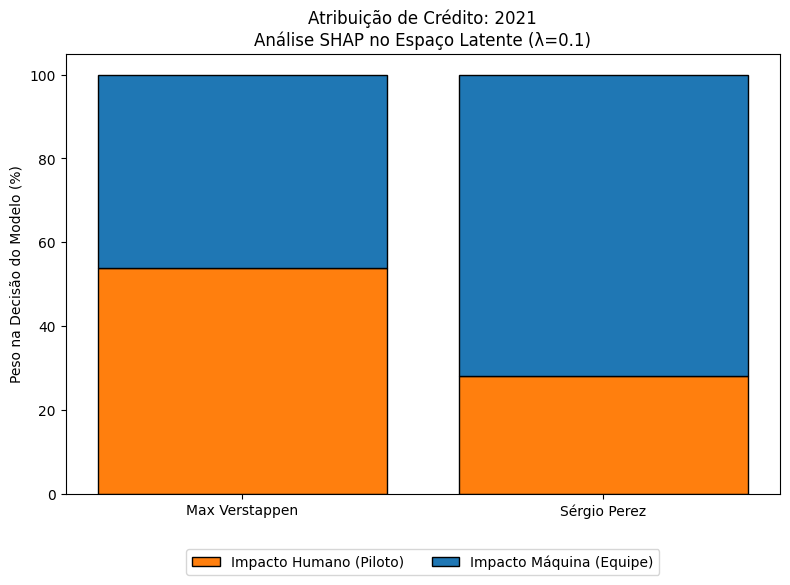

In [3]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO DA FLAG ---
EXCLUDE_TRACK_ENCODER = False # Alterne aqui conforme necessário
# ---------------------------

sys.path.append(os.path.abspath("src"))
from train import prepare_data_and_graph
from models.pipeline_fusion import F1OrthogonalPipeline

# 1. Configurações Iniciais
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_, _, test_loader, graph_data = prepare_data_and_graph()
graph_data = graph_data.to(device)

print(f"Carregando modelo (Excluir Pista: {EXCLUDE_TRACK_ENCODER})...")
num_nodes_dict = {nt: graph_data[nt].num_nodes for nt in graph_data.node_types}
model = F1OrthogonalPipeline(num_nodes_dict=num_nodes_dict, latent_dim=8).to(device)
model.load_state_dict(torch.load("output/models/model_orthogonal.pth", map_location=device))
model.eval()

# 2. Busca de dados e Tensores
RACE_YEAR = 2021
RACE_ROUND = 5
DRIVER_MAX_ID = 829 
DRIVER_LEWIS_ID = 3

df_instances = pd.read_csv("output/dataset/instances.csv")
abu_dhabi_df = df_instances[(df_instances['year'] == RACE_YEAR) & (df_instances['round'] == RACE_ROUND)]
max_row = abu_dhabi_df[abu_dhabi_df['driverId'] == DRIVER_MAX_ID].iloc[0]
lewis_row = abu_dhabi_df[abu_dhabi_df['driverId'] == DRIVER_LEWIS_ID].iloc[0]

driver_features = ['avg_qualifying_pos', 'teammate_delta', 'crash_rate', 'podium_rate', 'experience', 'points_per_finish']
track_features = ['altitude_m', 'length_m', 'corners_count', 'rotation', 'avg_track_temp']

def get_instance_tensors(row):
    x_d = torch.tensor(row[driver_features].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    x_t = torch.tensor(row[track_features].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    c_id = torch.tensor([int(row['constructorId'])], dtype=torch.long).to(device)
    return x_d, x_t, c_id

max_x_d, max_x_t, max_c_id = get_instance_tensors(max_row)
lewis_x_d, lewis_x_t, lewis_c_id = get_instance_tensors(lewis_row)

# 3. Extração Dinâmica
def get_fused_vector(x_d, x_t, c_id):
    with torch.no_grad():
        v_piloto = model.driver_encoder(x_d)
        v_equipe = model.team_encoder(graph_data.x_dict, graph_data.edge_index_dict, c_id)
        
        if EXCLUDE_TRACK_ENCODER:
            return torch.cat([v_piloto, v_equipe], dim=-1) # (1, 16)
        else:
            v_pista = model.track_encoder(x_t)
            return torch.cat([v_piloto, v_equipe, v_pista], dim=-1) # (1, 24)

max_fused = get_fused_vector(max_x_d, max_x_t, max_c_id)
lewis_fused = get_fused_vector(lewis_x_d, lewis_x_t, lewis_c_id)
X_eval = torch.cat([max_fused, lewis_fused], dim=0)

# 4. Cálculo SHAP Dinâmico (Fundo Realista)
background_list = []
with torch.no_grad():
    for batch in test_loader:
        x_d, x_t, c_ids, _ = [b.to(device) for b in batch]
        v_p = model.driver_encoder(x_d)
        v_e = model.team_encoder(graph_data.x_dict, graph_data.edge_index_dict, c_ids)
        if EXCLUDE_TRACK_ENCODER:
            v_f = torch.cat([v_p, v_e], dim=-1)
        else:
            v_t = model.track_encoder(x_t)
            v_f = torch.cat([v_p, v_e, v_t], dim=-1)
        background_list.append(v_f.cpu().numpy())
        if sum(len(b) for b in background_list) >= 50:
            break
background_np = np.concatenate(background_list, axis=0)[:50]
explainer = shap.KernelExplainer(
    lambda x: model.classifier(torch.tensor(x, dtype=torch.float32).to(device)).sigmoid().detach().cpu().numpy(), 
    background_np
)
shap_vals = explainer.shap_values(X_eval.cpu().numpy())
background_list = []
with torch.no_grad():
    for batch in test_loader:
        x_d, x_t, c_ids, _ = [b.to(device) for b in batch]
        v_p = model.driver_encoder(x_d)
        v_e = model.team_encoder(graph_data.x_dict, graph_data.edge_index_dict, c_ids)
        if EXCLUDE_TRACK_ENCODER:
            v_f = torch.cat([v_p, v_e], dim=-1)
        else:
            v_t = model.track_encoder(x_t)
            v_f = torch.cat([v_p, v_e, v_t], dim=-1)
        background_list.append(v_f.cpu().numpy())
        if sum(len(b) for b in background_list) >= 50:
            break
background_np = np.concatenate(background_list, axis=0)[:50]

# 5. Agregação Dinâmica
def summarize_blocks(shap_array):
    abs_shap = np.abs(shap_array)
    impact_piloto = np.sum(abs_shap[0:8])
    impact_equipe = np.sum(abs_shap[8:16])
    if not EXCLUDE_TRACK_ENCODER:
        impact_pista = np.sum(abs_shap[16:24])
        total = impact_piloto + impact_equipe + impact_pista
        return (impact_piloto/total)*100, (impact_equipe/total)*100, (impact_pista/total)*100
    else:
        total = impact_piloto + impact_equipe
        return (impact_piloto/total)*100, (impact_equipe/total)*100, 0.0

max_impact = summarize_blocks(shap_vals[0])
lewis_impact = summarize_blocks(shap_vals[1])

print("\n" + "="*50)
print(" RESULTADO SHAP: GP DE ABU DHABI 2021")
print("="*50)
print(f"MAX VERSTAPPEN : Piloto {max_impact[0]:.1f}% | Equipe {max_impact[1]:.1f}% | Pista {max_impact[2]:.1f}%")
print(f"LEWIS HAMILTON : Piloto {lewis_impact[0]:.1f}% | Equipe {lewis_impact[1]:.1f}% | Pista {lewis_impact[2]:.1f}%")

# Gráfico
labels = ['Max Verstappen', 'Sérgio Perez']
piloto_vals = [max_impact[0], lewis_impact[0]]
equipe_vals = [max_impact[1], lewis_impact[1]]

plt.figure(figsize=(8, 6))
plt.bar(labels, piloto_vals, label='Impacto Humano (Piloto)', color='#ff7f0e', edgecolor='black')
plt.bar(labels, equipe_vals, bottom=piloto_vals, label='Impacto Máquina (Equipe)', color='#1f77b4', edgecolor='black')
plt.ylabel("Peso na Decisão do Modelo (%)")
plt.title("Atribuição de Crédito: 2021\nAnálise SHAP no Espaço Latente (λ=0.1)")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()
plt.show()

## Mundos Paralelos - Transferência de Pilotos